In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import MinMaxScaler
import warnings

# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


traning_loss = []
accuracy = []


Using device: cpu


Generic Traing model

In [50]:
model_results = {}

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-5, name="Model"):
    """
    Generic training loop for regression tasks with validation.
    """
    # Move model to device (GPU or CPU)
    model = model.to(device)

    # Loss function for regression
    criterion = nn.MSELoss()

    # Optimizer (SGD with momentum)
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    # regularazitaiton 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )


    print(f"\nTraining {name} for {epochs} epochs...")
    start_time = time.time()

    final_val_loss = 0.0

    model_results[name] = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "mae": []
    }

    # all_y = []
    # for x, y in train_loader:
    #     all_y.append(y)
    # all_y = torch.cat(all_y)
    # print("Y min:", all_y.min().item())
    # print("Y max:", all_y.max().item())
    # print("Y NaN:", torch.isnan(all_y).sum().item())
    # print("Y Inf:", torch.isinf(all_y).sum().item())

    


    for epoch in range(epochs):
       # --- Training Phase ---
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs.squeeze(), y)
            loss.backward()
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            # print(f"Gradient norm: {total_norm:.4f}")
            optimizer.step()

            running_loss += loss.item()
            # break

        train_loss = running_loss / len(train_loader)
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        total = 0.0
        correct = 0.0
        mae = 0.0


        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs.squeeze(), y)
                val_loss += loss.item()
                mae += torch.mean(torch.abs(outputs - y)).item()
                # total += y.numel()
                epsilon = 1e-8
                # this is numerica and it predicet the actual price of stock +- 30% the acutal closing
                # correct += ((torch.abs(outputs.squeeze() - y) / (y + epsilon)) < 0.3).sum().item()
                # Did prediction and actual agree on direction?
                correct += ((outputs.squeeze() > 0) == (y > 0)).sum().item()
                total += y.numel()


        final_val_loss = val_loss / len(val_loader)
        final_val_acc = 100 * correct / total
        final_mae = mae / len(val_loader)

        model_results[name]["train_loss"].append(train_loss)
        model_results[name]["val_loss"].append(final_val_loss)
        model_results[name]["val_acc"].append(final_val_acc)
        model_results[name]["mae"].append(final_mae)

        print(f"  Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {final_val_loss:.4f} | Val Acc: {final_val_acc:.2f}% | MEA: {final_mae:.2f}")

    end_time = time.time()
    duration = end_time - start_time
    print(f"{name} - Final Accuracy: {final_val_acc:.2f}%, Time: {duration:.2f}s")

    return final_val_acc, final_val_loss, duration

Data preparation

In [4]:
# Load the dataset
dataset = load_dataset("Adilbai/stock-dataset")
df = dataset["train"].to_pandas()
print(df.columns)
# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique tickers: {df['Ticker'].nunique()}")

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10',
       'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3',
       'Volatility_lag_5', 'Volatility_lag_10', 'Future_Return_1d',

In [27]:
# Sort by date for each ticker
df = df.sort_values(['Ticker', 'Date'])
# print(df)

# Only use numerical columns for prediction
# for price and volume I am using these
# features = ['Open', 'High', 'Low', 'Close', 'Volume']
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26',
    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
    'BB_Width', 'BB_Position', 'Volatility',
    'Price_Change', 'High_Low_Ratio', 'Open_Close_Ratio',
    'Volume_SMA', 'Volume_Ratio',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3',
    'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3',
    'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3',
    'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3'
]
print(len(features))

# for trends use this features
# ['SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26']

# ticker = df['Ticker'].unique()
# print(ticker)
# df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)

tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA'] 
# all_dfs = []

# for ticker in tickers:
#     df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)
    
#     # Scale each ticker independently
#     scaler = MinMaxScaler()
#     df_ticker[features] = scaler.fit_transform(df_ticker[features])
    
#     all_dfs.append(df_ticker)

# # Combine all tickers into one training set
# df_combined = pd.concat(all_dfs).reset_index(drop=True)
# # print(df_ticker["Ticker"])

34


In [33]:
# class StockDataset(Dataset):
#     def __init__(self, df, seq_len=10):
#         self.df = df.reset_index(drop=True)
#         self.seq_len = seq_len
#         self.features = features

#     def __len__(self):
#         return len(self.df) - self.seq_len - 1

#     def __getitem__(self, idx):
#         x = self.df[self.features].iloc[idx:idx+self.seq_len].values

#         current_close = self.df['Close'].iloc[idx+self.seq_len-1]
#         next_close    = self.df['Close'].iloc[idx+self.seq_len]

#         y = (next_close - current_close) / (current_close + 1e-8)
#         return (
#             torch.tensor(x, dtype=torch.float32),
#             torch.tensor(y, dtype=torch.float32)
#         )
class StockDataset(Dataset):
    def __init__(self, df, features, seq_len=20):  # features passed in, seq_len default 25
        self.df       = df.reset_index(drop=True)
        self.seq_len  = seq_len
        self.features = features                   # no longer hardcoded

    def __len__(self):
        return len(self.df) - self.seq_len - 1

    # def __getitem__(self, idx):
    #     x = self.df[self.features].iloc[idx:idx+self.seq_len].values

    #     current_close = self.df['Close'].iloc[idx+self.seq_len-1]
    #     next_close    = self.df['Close'].iloc[idx+self.seq_len]

    #     y = (next_close - current_close) / (current_close + 1e-8)

    #     return (
    #         torch.tensor(x, dtype=torch.float32),
    #         torch.tensor(y, dtype=torch.float32)
    #     )
    def __getitem__(self, idx):
        x = self.df[self.features].iloc[idx:idx+self.seq_len].values
        y = self.df['Target'].iloc[idx+self.seq_len]  # precomputed, clean

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(float(y), dtype=torch.float32)
    )

In [29]:
# total_size = len(df_combined)
# train_size = int(0.7 * total_size)
# val_size   = int(0.15 * total_size)
# test_size  = total_size - train_size - val_size

# train_df = df_combined.iloc[:train_size].copy()
# val_df   = df_combined.iloc[train_size:train_size+val_size].copy()
# test_df  = df_combined.iloc[train_size+val_size:].copy()

# # scaler = MinMaxScaler()

# train_df[features] = scaler.fit_transform(train_df[features])
# val_df[features]   = scaler.transform(val_df[features])
# test_df[features]  = scaler.transform(test_df[features])


# seq_len = 25

# train_dataset = StockDataset(train_df, seq_len)
# val_dataset   = StockDataset(val_df, seq_len)
# test_dataset  = StockDataset(test_df, seq_len)


# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
# val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
# test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# print(f" Test: {len(test_dataset)}, Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# print(f"Test: {len(test_set)}, Train: {len(train_set)}, Val: {len(val_set)}")

In [53]:
train_dfs, val_dfs, test_dfs = [], [], []

for ticker in tickers:
    df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)

    df_ticker['Target'] = (
        df_ticker['Close'].shift(-1) - df_ticker['Close']
    ) / (df_ticker['Close'] + 1e-8)
    df_ticker['Target'] = df_ticker['Target'].clip(-0.1, 0.1)

    df_ticker = df_ticker.dropna(subset=['Target']).reset_index(drop=True)
    
    # Split each ticker chronologically BEFORE scaling
    n         = len(df_ticker)
    train_end = int(0.7  * n)
    val_end   = int(0.85 * n)
    
    train_part = df_ticker.iloc[:train_end].copy()
    val_part   = df_ticker.iloc[train_end:val_end].copy()
    test_part  = df_ticker.iloc[val_end:].copy()
    

    # Scale each ticker independently — fit on train only
    scaler = MinMaxScaler()
    train_part[features] = scaler.fit_transform(train_part[features])
    val_part[features]   = scaler.transform(val_part[features])
    test_part[features]  = scaler.transform(test_part[features])
    
    train_dfs.append(train_part)
    val_dfs.append(val_part)
    test_dfs.append(test_part)

# Combine splits across all tickers
train_df = pd.concat(train_dfs).reset_index(drop=True)
val_df   = pd.concat(val_dfs).reset_index(drop=True)
test_df  = pd.concat(test_dfs).reset_index(drop=True)

# Datasets and DataLoaders
seq_len = 25

train_dataset = StockDataset(train_df, features, seq_len)
val_dataset   = StockDataset(val_df,   features, seq_len)
test_dataset  = StockDataset(test_df,  features, seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


# print("NaN in train_df:", train_df[features].isna().sum().sum())
# print("Inf in train_df:", np.isinf(train_df[features].values).sum())

# sample_x, sample_y = train_dataset[0]
# print("X shape:", sample_x.shape)
# print("X min:", sample_x.min().item())
# print("X max:", sample_x.max().item())  # should be 0-1
# print("Y value:", sample_y.item()) 

# print(train_df[features].describe())

# print("Features not in df:", [f for f in features if f not in train_df.columns])
# print("\nFeature value ranges:")
# print(train_df[features].max()) 

Train: 4324, Val: 909, Test: 909


In [54]:
# store the result
results = {}

Simple 1D CNN for practices

In [58]:
class SimpleCNN(nn.Module):
    def __init__(self, seq_len=25, n_features=len(features), n_classes=1):
        super(SimpleCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)

        # Block 2
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)

        # Block 3
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        self.relu        = nn.ReLU()
        self.drop_conv   = nn.Dropout(0.4)   # after conv blocks
        self.drop_fc     = nn.Dropout(0.5)   # after fc1

        # AdaptiveAvgPool — always outputs size 1, no size crashes
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.flatten     = nn.Flatten()

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, n_classes)

        # Weight initialization
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # [batch, seq_len, features] -> [batch, features, seq_len]
        x = x.permute(0, 2, 1)

        # Conv Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop_conv(x)

        # Conv Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.drop_conv(x)

        # Conv Block 3
        x = self.relu(self.bn3(self.conv3(x)))

        # Pool -> Flatten -> FC
        x = self.global_pool(x)   # [batch, 128, 1]
        x = self.flatten(x)       # [batch, 128]
        x = self.relu(self.fc1(x))
        x = self.drop_fc(x)
        return self.fc2(x)        # [batch, 1]

# Initialize and train our complex CNN
my_cnn = SimpleCNN()
params_cnn = sum(p.numel() for p in my_cnn.parameters())
print(f"SimpleCNN Total Parameters: {params_cnn:,}")
acc, loss, t = train_model(my_cnn, train_loader, val_loader, epochs=15, name="Simple CNN")
results['Simple CNN'] = {'acc': acc, 'loss': loss, 'time': t, 'params': params_cnn}

SimpleCNN Total Parameters: 42,977

Training Simple CNN for 15 epochs...
  Epoch [1/15] | Train Loss: 0.3480 | Val Loss: 0.1883 | Val Acc: 45.65% | MEA: 0.30
  Epoch [2/15] | Train Loss: 0.3150 | Val Loss: 0.1902 | Val Acc: 44.77% | MEA: 0.30
  Epoch [3/15] | Train Loss: 0.2850 | Val Loss: 0.1426 | Val Acc: 46.86% | MEA: 0.27
  Epoch [4/15] | Train Loss: 0.2504 | Val Loss: 0.1198 | Val Acc: 46.97% | MEA: 0.26
  Epoch [5/15] | Train Loss: 0.2141 | Val Loss: 0.0683 | Val Acc: 48.84% | MEA: 0.20
  Epoch [6/15] | Train Loss: 0.1946 | Val Loss: 0.0614 | Val Acc: 47.96% | MEA: 0.20
  Epoch [7/15] | Train Loss: 0.1818 | Val Loss: 0.0523 | Val Acc: 48.84% | MEA: 0.18
  Epoch [8/15] | Train Loss: 0.1557 | Val Loss: 0.0422 | Val Acc: 50.17% | MEA: 0.16
  Epoch [9/15] | Train Loss: 0.1329 | Val Loss: 0.0361 | Val Acc: 50.39% | MEA: 0.14
  Epoch [10/15] | Train Loss: 0.1247 | Val Loss: 0.0344 | Val Acc: 49.39% | MEA: 0.14
  Epoch [11/15] | Train Loss: 0.1041 | Val Loss: 0.0344 | Val Acc: 50.72% | 

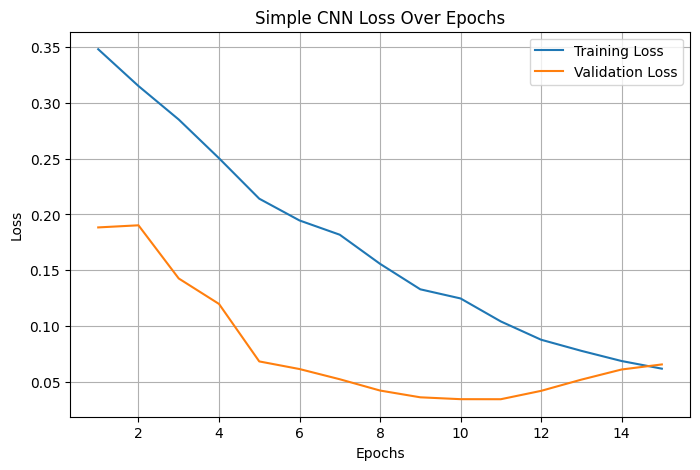

In [59]:
model_name = 'Simple CNN'

# print(model_results) 
train_loss = model_results[model_name]['train_loss']
val_loss = model_results[model_name]['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'{model_name} Loss Over Epochs')
plt.legend()
plt.grid(True)

plt.show()